Δv (SOC) = 0.14697445305292245 eV
EgA, EgB = 0.0 0.14697445305292245
k-space weight wk = 1.24839828085632e-05

--- A (Ev_top) run summary ---
a(Å) = 3.1680123806
Nk kept = 253 of 9216

--- B (Ev_low) run summary ---
a(Å) = 3.1680123806
Nk kept = 253 of 9216

--- Dirac Hamiltonian sanity checks (A) ---
K_plus offdiag H[0,1] = (kx + i ky) * a * t = (-0.9424777960769383-0.30229989403901575j)
K_minus offdiag H[0,1] = (-kx + i ky) * a * t = (0.9424777960769383-0.30229989403901575j)
Conjugate check K_plus: (-0.9424777960769383+0.30229989403901575j) == (-0.9424777960769383+0.30229989403901575j)
Conjugate check K_minus: (0.9424777960769383+0.30229989403901575j) == (0.9424777960769383+0.30229989403901575j)
K_plus Hermitian? True
K_minus Hermitian? True
dphi = 0.24632101651979887   angle(Hp[i,j]) = 2.8952716370699942


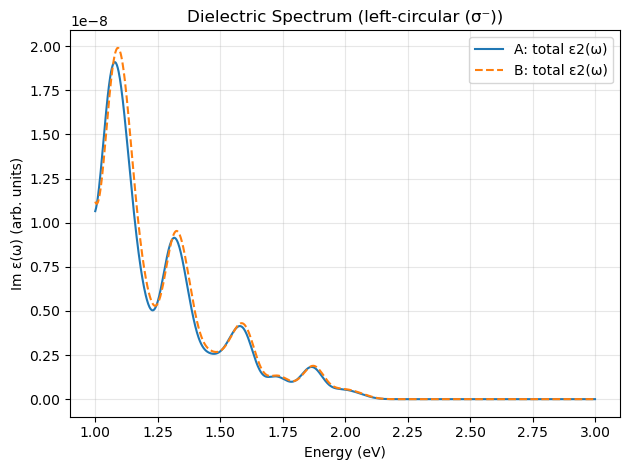

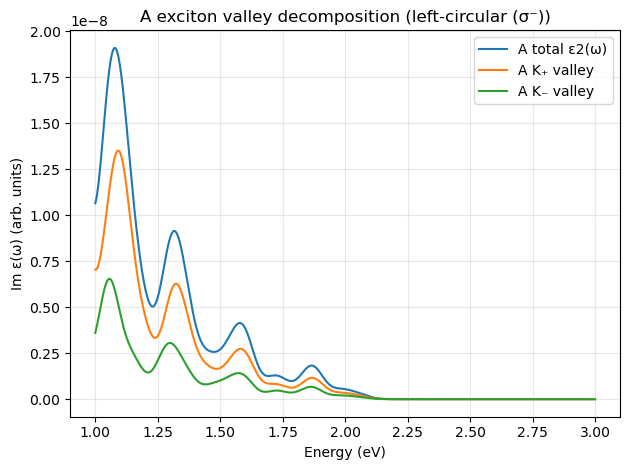

In [ ]:
# ===== One-cell driver: parameters.json + auto SOC + run + plot =====
import json
import numpy as np
import matplotlib.pyplot as plt
import importlib

import QE_xml_read, K_P_dirac, BSE_hamiltonian, dielectric_function
importlib.reload(QE_xml_read)
importlib.reload(K_P_dirac)
importlib.reload(BSE_hamiltonian)
importlib.reload(dielectric_function)

from QE_xml_read import (
    build_param_list_from_qe_xml,
    compute_k_weight_from_qe_xml,
    extract_soc_splitting_at_valleys,
    detect_soc_from_qe_xml,
)
from K_P_dirac import build_two_valley_dirac_series
from dielectric_function import compute_dielectric_for_two_valleys

# ---- 0) Load parameters.json ----
PARAM_FILE = "parameters.json"
with open(PARAM_FILE, "r") as f:
    P = json.load(f)

xml_path = P["qe"]["xml_path"]

# ---- 1) k-space weight (wk) ----
kws = P["qe"]["k_weight"]["source"].lower()
if kws == "xml":
    wk = compute_k_weight_from_qe_xml(xml_path)
else:
    wk = float(P["qe"]["k_weight"]["value"])
print("wk =", wk)

# ---- 2) SOC auto-detect ----
soc_cfg = P["qe"]["soc"]
mode = soc_cfg.get("mode", "auto").lower()

if mode == "auto":
    soc_info = detect_soc_from_qe_xml(xml_path, split_tol_ev=float(soc_cfg.get("split_tol_ev", 1e-3)))
    soc_on = bool(soc_info["soc_on"])
    print("SOC detect:", soc_info["method"], "| soc_on =", soc_on)
elif mode == "on":
    soc_on = True
    print("SOC forced ON")
else:
    soc_on = False
    print("SOC forced OFF")

# ---- 3) Read valley-edge energies from XML (works either way) ----
valley_key = soc_cfg.get("valley_for_gap", "K")  # "K" or "Kp"
spl = extract_soc_splitting_at_valleys(xml_path)

Ec_min  = float(spl[valley_key]["Ec_min"])
Ev_top  = float(spl[valley_key]["Ev_top"])
Ev_low  = float(spl[valley_key]["Ev_low"])
delta_v = float(spl[valley_key]["delta_v"])
delta_c = float(spl[valley_key]["delta_c"]) if spl[valley_key]["delta_c"] is not None else float("nan")

EgA = Ec_min - Ev_top
EgB = Ec_min - Ev_low

# SOC-off reference gap (use average of split valence as an "unsplit" proxy if SOC is on)
Ev_avg = 0.5 * (Ev_top + Ev_low)
Eg0 = Ec_min - Ev_avg

print(f"Valley used = {valley_key}")
print(f"Ec_min={Ec_min:.6f} eV, Ev_top={Ev_top:.6f} eV, Ev_low={Ev_low:.6f} eV")
print(f"delta_v={delta_v:.6f} eV, delta_c={delta_c:.6f} eV")
print(f"Eg0 (SOC-off ref)={Eg0:.6f} eV | EgA={EgA:.6f} eV | EgB={EgB:.6f} eV")

# ---- 4) Build BSE-kernel overrides from JSON ----
K = P["bse"]["kernel"]
bse_kwargs = dict(
    chi_default=float(K["chi_value"]),
    chi_units_default=str(K["chi_units"]),
    chi_is_inverse_default=bool(K["chi_is_inverse"]),
    k_units_default=str(K["k_units"]),
    k_eps_default=float(K["k_eps"]),
)

# ---- 5) Optics controls ----
O = P["optics"]
pol = O["polarization"]
eta = float(O["eta_eV"])
omega_min = float(O["omega_min_eV"])
omega_max = float(O["omega_max_eV"])
omega_points = int(O["omega_points"])
prefactor = float(O["prefactor"])
include_freq = bool(O["include_frequency_factor"])
broadening = str(O["broadening"])

# ---- 6) k·p model controls ----
kp = P["kp_model"]
t = float(kp["t_eV"])
alpha = float(kp["alpha"])
Ev_model = float(kp.get("Ev_eV", 0.0))
Ec_override = kp.get("Ec_eV", None)          # if not null, forces Ec for all runs
a_override = kp.get("a_override_A", None)    # if not null, forces lattice constant
valley_center = kp.get("valley_center", "K")

def run_gap(Eg, label):
    # only gap matters in your current Dirac setup; set Ec = Ev + Eg unless overridden
    Ec_model = float(Ec_override) if Ec_override is not None else (Ev_model + float(Eg))

    param_list, info = build_param_list_from_qe_xml(
        xml_path, Ev=Ev_model, Ec=Ec_model, alpha=alpha, valley=valley_center
    )

    aA = float(a_override) if a_override is not None else float(info["a_A"])
    series = build_two_valley_dirac_series(param_list, a=aA, t=t)

    res = compute_dielectric_for_two_valleys(
        series,
        k_weight=wk,
        polarization=pol,
        eta=eta,
        omega_min=omega_min, omega_max=omega_max, omega_points=omega_points,
        prefactor=prefactor,
        include_frequency_factor=include_freq,
        broadening=broadening,
        bse_kwargs=bse_kwargs,
    )
    print(f"[{label}] a={aA:.6f} Å | Nk_kept={info['Nk_kept']} | Eg_used={Eg:.6f} eV")
    return res

# ---- 7) Run SOC-off reference ----
res0 = run_gap(Eg0, "SOC-OFF ref")

# ---- 8) Run SOC-on A/B if SOC detected ----
resA = resB = None
if soc_on:
    resA = run_gap(EgA, "SOC-ON  A")
    resB = run_gap(EgB, "SOC-ON  B")

# ---- 9) Plot: overlay spectra ----
plt.figure()
plt.plot(res0.omega, res0.eps2_total, label="SOC-off reference (Eg0)")
if soc_on:
    plt.plot(resA.omega, resA.eps2_total, label="SOC-on A (EgA)")
    plt.plot(resB.omega, resB.eps2_total, label="SOC-on B (EgB)", linestyle="--")
plt.xlabel("Energy (eV)")
plt.ylabel("Im ε(ω) (arb.)")
plt.title(f"Absorption overlay | pol={pol} | eta={eta} eV")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# ---- 10) Plot: valley decomposition for each run ----
def plot_valleys(res, title):
    plt.figure()
    plt.plot(res.omega, res.eps2_total, label="total")
    plt.plot(res.omega, res.eps2_K_plus, label="K+")
    plt.plot(res.omega, res.eps2_K_minus, label="K-")
    plt.xlabel("Energy (eV)")
    plt.ylabel("Im ε(ω) (arb.)")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_valleys(res0, f"SOC-off reference valley decomposition | pol={pol}")

if soc_on:
    plot_valleys(resA, f"SOC-on A valley decomposition | pol={pol}")
    plot_valleys(resB, f"SOC-on B valley decomposition | pol={pol}")
# ===== end cell =====